# Importação de Pacotes

In [1]:
#leitura da base de dados
import pandas as pd
from pathlib import Path
import parquet

#modelo preditivo escolhido
from sklearn.ensemble import GradientBoostingClassifier

#validação cruzada
from sklearn.experimental import enable_halving_search_cv
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV, HalvingGridSearchCV
import numpy as np

#métricas
import matplotlib
from sklearn.metrics import accuracy_score, f1_score, recall_score, roc_auc_score, ConfusionMatrixDisplay, classification_report

#pipelines
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder, FunctionTransformer
from sklearn.compose import ColumnTransformer, TransformedTargetRegressor
from sklearn.impute import SimpleImputer
from sklearn.utils.class_weight import compute_sample_weight

In [2]:
def estimadores(modelo, X_test, y_test):
    y_pred = modelo.predict(X_test)
    y_proba = modelo.predict_proba(X_test)

    acuracia = accuracy_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred, average='weighted')
    f1 = f1_score(y_test, y_pred, average='weighted')

    roc_auc = roc_auc_score(
        y_test,
        y_proba,
        multi_class='ovr',
        average='weighted'
    )

    ConfusionMatrixDisplay.from_estimator(modelo, X_test, y_test)

    print(f"""
        Acurácia: {acuracia:.3f}
        Recall (weighted): {recall:.3f}
        F1-score (weighted): {f1:.3f}
        ROC AUC (ovr): {roc_auc:.3f}
        """)

    print(classification_report(y_test, y_pred))

## Leitura DataFrame

In [3]:
direcao = Path("../..") / "data"
caminho = direcao / "erro_medico_tidy_final.parquet"


df_erro_simples = pd.read_parquet(caminho)

df = df_erro_simples

### Escolha do Modelo

In [4]:
modelo= GradientBoostingClassifier()

### Escolha dos HiperParâmetros

In [5]:
parametros = {
    'modelo__n_estimators': [100],
    'modelo__max_depth': [2, 6],
    'modelo__max_leaf_nodes': [10],
    'modelo__learning_rate': [0.05, 0.2]
    }

In [6]:
df.head(2)

,n_processo,escopo,data_de_disponibilizacao,decisao,morais_ped,morais_rec,materiais_ped,materiais_rec,classe,assunto,...,tem_hospital,tem_plano_saude,tem_ente_publico,tem_medico_individual,n_adv_autor,n_adv_reu,tem_perito,tem_denuncia_lide,tem_assistente,resumo_caso
0,10169222220248260564,sim,2026-02-24,proced,100000.0,55000.0,-1.0,-1.0,Procedimento Comum Cível,Serviços de Saúde,...,0.0,1.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,## Identificação do Caso\n- Número do processo...
1,10003518420258260355,sim,2026-02-23,improced,151800.0,0.0,75900.0,0.0,Procedimento Comum Cível,Serviços de Saúde,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,## Identificação do Caso\n- **Número do proces...


In [7]:
df.columns

Index(['n_processo', 'escopo', 'data_de_disponibilizacao', 'decisao',
       'morais_ped', 'morais_rec', 'materiais_ped', 'materiais_rec', 'classe',
       'assunto', 'foro', 'vara', 'juiz', 'data_distribuicao', 'valor_acao',
       'area', 'n_autores', 'n_reus', 'tem_hospital', 'tem_plano_saude',
       'tem_ente_publico', 'tem_medico_individual', 'n_adv_autor', 'n_adv_reu',
       'tem_perito', 'tem_denuncia_lide', 'tem_assistente', 'resumo_caso'],
      dtype='object')

# Aplicação de Pipelines

## Pipeline Padrão

In [8]:
lista_X = ['valor_acao','n_autores', 'n_reus', 'tem_hospital', 'tem_plano_saude',
           'tem_ente_publico', 'tem_medico_individual', 'n_adv_autor', 'n_adv_reu',
           'tem_perito', 'tem_denuncia_lide', 'tem_assistente']

X = df[lista_X]

y = df["decisao"]

X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.3, random_state=22)

num_prep = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', num_prep, lista_X),
    ])

pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('modelo', modelo)
    ])

searchCV_pipeline = RandomizedSearchCV(
    pipeline,
    parametros,
    scoring='roc_auc_ovr',
    refit= True,
    cv=5
)

# balanceamento por sample_weight (GradientBoostingClassifier não aceita class_weight)
sample_weight = compute_sample_weight('balanced', y_train)
searchCV_pipeline.fit(X_train, y_train, modelo__sample_weight=sample_weight)

c:\Users\peper\OneDrive\Documentos\PIBIC\.venv\Lib\site-packages\sklearn\model_selection\_search.py:317: UserWarning: The total space of parameters 4 is smaller than n_iter=10. Running 4 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


,estimator,Pipeline(step...lassifier())])
,param_distributions,"{'modelo__learning_rate': [0.05, 0.2], 'modelo__max_depth': [2, 6], 'modelo__max_leaf_nodes': [10], 'modelo__n_estimators': [100]}"
,n_iter,10
,scoring,'roc_auc_ovr'
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,random_state,None
,error_score,nan



        Acurácia: 0.428
        Recall (weighted): 0.428
        F1-score (weighted): 0.457
        ROC AUC (ovr): 0.496
        
              precision    recall  f1-score   support

    improced       0.66      0.52      0.58       420
 parc_proced       0.17      0.23      0.19       123
      proced       0.15      0.25      0.19        72

    accuracy                           0.43       615
   macro avg       0.33      0.33      0.32       615
weighted avg       0.50      0.43      0.46       615



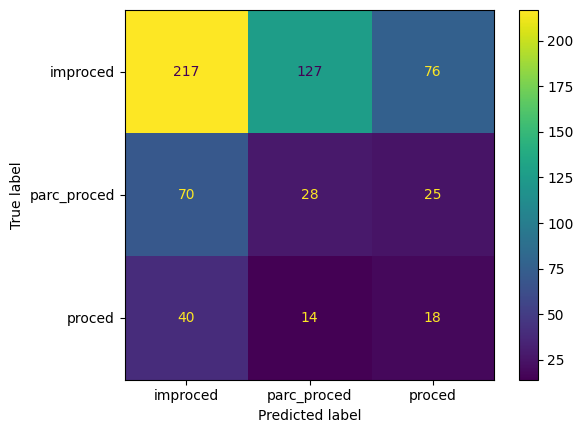

In [9]:
estimadores(searchCV_pipeline, X_test, y_test)

# Testando Variações no Pipeline

### Trocar 'roc_auc_ovr' por 'f1_macro'

In [10]:
lista_X = ['valor_acao','n_autores', 'n_reus', 'tem_hospital', 'tem_plano_saude',
           'tem_ente_publico', 'tem_medico_individual', 'n_adv_autor', 'n_adv_reu',
           'tem_perito', 'tem_denuncia_lide', 'tem_assistente']

X = df[lista_X]

y = df["decisao"]

X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.3, random_state=22)

num_prep = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', num_prep, lista_X),
    ])

pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('modelo', modelo)
    ])

searchCV_pipeline = RandomizedSearchCV(
    pipeline,
    parametros,
    scoring='f1_macro',
    refit= True,
    cv=5
)

# balanceamento por sample_weight (GradientBoostingClassifier não aceita class_weight)
sample_weight = compute_sample_weight('balanced', y_train)
searchCV_pipeline.fit(X_train, y_train, modelo__sample_weight=sample_weight)

c:\Users\peper\OneDrive\Documentos\PIBIC\.venv\Lib\site-packages\sklearn\model_selection\_search.py:317: UserWarning: The total space of parameters 4 is smaller than n_iter=10. Running 4 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


,estimator,Pipeline(step...lassifier())])
,param_distributions,"{'modelo__learning_rate': [0.05, 0.2], 'modelo__max_depth': [2, 6], 'modelo__max_leaf_nodes': [10], 'modelo__n_estimators': [100]}"
,n_iter,10
,scoring,'f1_macro'
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,random_state,None
,error_score,nan



        Acurácia: 0.426
        Recall (weighted): 0.426
        F1-score (weighted): 0.456
        ROC AUC (ovr): 0.496
        
              precision    recall  f1-score   support

    improced       0.66      0.51      0.58       420
 parc_proced       0.16      0.23      0.19       123
      proced       0.15      0.25      0.19        72

    accuracy                           0.43       615
   macro avg       0.33      0.33      0.32       615
weighted avg       0.50      0.43      0.46       615



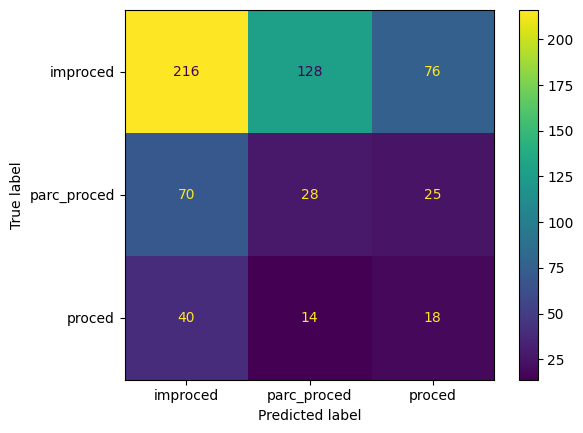

In [11]:
estimadores(searchCV_pipeline, X_test, y_test)

### stratify=y em train_test_split

In [12]:
lista_X = ['valor_acao','n_autores', 'n_reus', 'tem_hospital', 'tem_plano_saude',
           'tem_ente_publico', 'tem_medico_individual', 'n_adv_autor', 'n_adv_reu',
           'tem_perito', 'tem_denuncia_lide', 'tem_assistente']

X = df[lista_X]

y = df["decisao"]

X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.3, random_state=22, stratify=y)

num_prep = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', num_prep, lista_X),
    ])

pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('modelo', modelo)
    ])

searchCV_pipeline = RandomizedSearchCV(
    pipeline,
    parametros,
    scoring='roc_auc_ovr',
    refit= True,
    cv=5
)

# balanceamento por sample_weight (GradientBoostingClassifier não aceita class_weight)
sample_weight = compute_sample_weight('balanced', y_train)
searchCV_pipeline.fit(X_train, y_train, modelo__sample_weight=sample_weight)

c:\Users\peper\OneDrive\Documentos\PIBIC\.venv\Lib\site-packages\sklearn\model_selection\_search.py:317: UserWarning: The total space of parameters 4 is smaller than n_iter=10. Running 4 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


,estimator,Pipeline(step...lassifier())])
,param_distributions,"{'modelo__learning_rate': [0.05, 0.2], 'modelo__max_depth': [2, 6], 'modelo__max_leaf_nodes': [10], 'modelo__n_estimators': [100]}"
,n_iter,10
,scoring,'roc_auc_ovr'
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,random_state,None
,error_score,nan



        Acurácia: 0.411
        Recall (weighted): 0.411
        F1-score (weighted): 0.459
        ROC AUC (ovr): 0.579
        
              precision    recall  f1-score   support

    improced       0.73      0.45      0.56       425
 parc_proced       0.24      0.31      0.27       124
      proced       0.12      0.35      0.18        66

    accuracy                           0.41       615
   macro avg       0.36      0.37      0.33       615
weighted avg       0.57      0.41      0.46       615



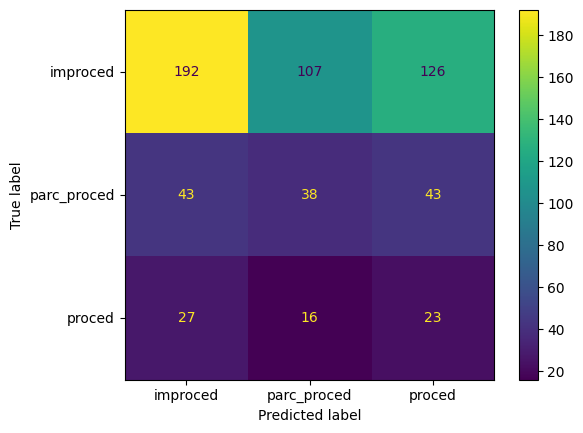

In [13]:
estimadores(searchCV_pipeline, X_test, y_test)